In [1]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import permutation_test_score

In [ ]:
sz_nc = np.load('COBRE_results/correlations/cobre_corr_control_74_232_232.npy')[:,:200,:200]
sz_p = np.load('COBRE_results/correlations/cobre_corr_patient_71_232_232.npy')[:,:200,:200]

asd_nc = np.load('ABIDE_results/correlations/abide_corr_control_105_232_232.npy')[:,:200,:200]
asd_p = np.load('ABIDE_results/correlations/abide_corr_patient_79_232_232.npy')[:,:200,:200]

adhd_nc = np.load('ADHD200_results/correlations/adhd_corr_control_98_232_232.npy')[:,:200,:200]
adhd_p = np.load('ADHD200_results/correlations/adhd_corr_patient_118_232_232.npy')[:,:200,:200]

# calculate mean and std for NC group (axis=0 means across subjects)
sz_nc_mean = np.mean(sz_nc, axis=0)
sz_nc_std = np.std(sz_nc, axis=0)

asd_nc_mean = np.mean(asd_nc, axis=0)
asd_nc_std = np.std(asd_nc, axis=0)

adhd_nc_mean = np.mean(adhd_nc, axis=0)
adhd_nc_std = np.std(adhd_nc, axis=0)

sz_nc_std[sz_nc_std == 0] = np.finfo(float).eps

asd_nc_std[asd_nc_std == 0] = np.finfo(float).eps

adhd_nc_std[adhd_nc_std == 0] = np.finfo(float).eps

# z_score = (scz_matrix - nc_mean) / nc_std
sz_p_z = (sz_p - sz_nc_mean) / sz_nc_std

asd_p_z = (asd_p - asd_nc_mean) / asd_nc_std

adhd_p_z = (adhd_p - adhd_nc_mean) / adhd_nc_std

In [ ]:
fc1 = np.concatenate((sz_p_z, asd_p_z, adhd_p_z),axis=0)
true_labels = np.array([0]*71 + [1]*79 + [2]*118)

def extract_uppertriangle(fc):
    # extract upper triangle (excluding diagonal) from each FC matrix
    idx = np.triu_indices(fc.shape[1], k=1)
    return fc[:, idx[0], idx[1]]


fc1_vec = extract_uppertriangle(fc1)  

X = fc1_vec

scaler = StandardScaler()
X_std = scaler.fit_transform(X)

(268, 10)


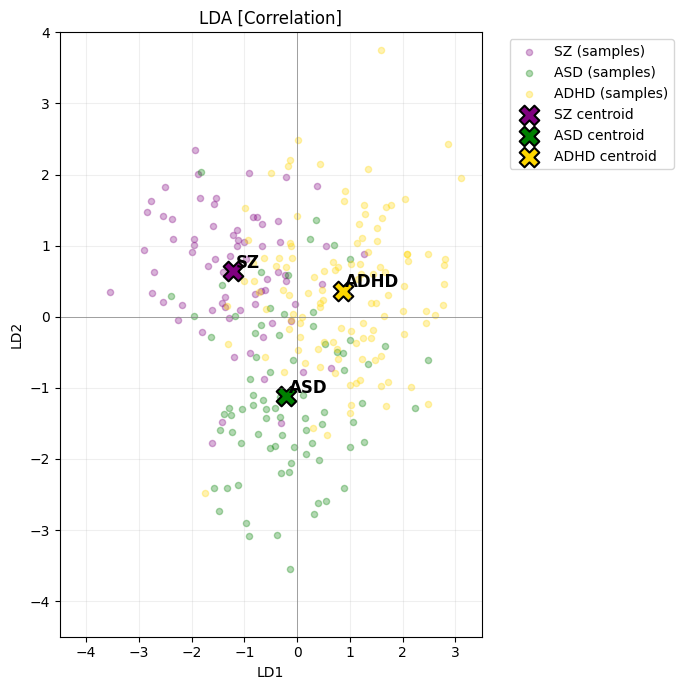

In [ ]:
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_std, true_labels)
# 0: SZ, 1: ASD, 2: ADHD
label_names = {0: "SZ", 1: "ASD", 2: "ADHD"}
colors = {0: "purple", 1: "green", 2: "gold"}

plt.figure(figsize=(7, 7))

# plot samples
for lab in [0, 1, 2]:
    pts = X_lda[true_labels == lab]
    plt.scatter(
        pts[:, 0], pts[:, 1],
        color=colors[lab],
        alpha=0.3,
        s=20,
        label=f"{label_names[lab]} (samples)"
    )

# plot cetroids
for lab in [0, 1, 2]:
    pts = X_lda[true_labels == lab]
    cx, cy = pts.mean(axis=0)
    plt.scatter(
        cx, cy,
        color=colors[lab],
        marker="X",
        s=200,
        edgecolor="black",
        linewidth=1.5,
        label=f"{label_names[lab]} centroid"
    )

    plt.text(cx + 0.05, cy + 0.05, label_names[lab],
             fontsize=12, weight="bold")

plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("LDA [Correlation]")
plt.axhline(0, color="gray", linewidth=0.5)
plt.axvline(0, color="gray", linewidth=0.5)
plt.xlim(-4.5, 3.5)
plt.ylim(-4.5, 4.0)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [7]:
score, perm_scores, p_value = permutation_test_score(
    lda,
    X_std,
    true_labels,
    cv=5,
    n_permutations=1000,
    scoring="accuracy",
    verbose=10,  
    n_jobs=-1     
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:   54.5s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:  2.9min
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:  3.6min
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:  4.2min
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:  4.8min
[Parallel(n_jobs=-1)]: Done  69 tasks      | elapsed:  6.0min
[Parallel(n_jobs=-1)]: Done  82 tasks      | elapsed:  7.2min
[Parallel(n_jobs=-1)]: Done  97 tasks      | elapsed:  8.8min
[Parallel(n_jobs=-1)]: Done 112 tasks      | elapsed: 10.0min
[Parallel(n_jobs=-1)]: Done 129 tasks      | elapsed: 11.8min
[Parallel(n_jobs=-1)]: Done 146 tasks      | elapsed: 13.1min
[Parallel(n_jobs=-1)]: Done 165 tasks      | elapsed: 15.0min
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed: 16

In [8]:
print(score)
print(perm_scores)
print(p_value)

0.6718378756114605
[0.4327044  0.43696716 0.3431167  0.39902166 0.41069182 0.36561845
 0.36191474 0.35821104 0.40300489 0.42173305 0.38448637 0.42907058
 0.35087352 0.35087352 0.34709993 0.35080363 0.32068484 0.37316562
 0.39895178 0.35429769 0.39538784 0.41076171 0.41069182 0.34381551
 0.4033543  0.33584906 0.31719078 0.4025856  0.44039133 0.40684836
 0.38791055 0.40286513 0.38441649 0.39545772 0.39161426 0.37624039
 0.34703005 0.41397624 0.36568833 0.35101328 0.42907058 0.41383648
 0.36191474 0.3802935  0.40272537 0.36904263 0.39895178 0.42138365
 0.36554857 0.42865129 0.3613557  0.40649895 0.40300489 0.39559748
 0.41048218 0.40279525 0.39923131 0.39881202 0.3431167  0.41006289
 0.39937107 0.40684836 0.41083159 0.38434661 0.41439553 0.38085255
 0.43654787 0.33577918 0.38085255 0.425297   0.43703704 0.38839972
 0.38043326 0.4628232  0.35073375 0.42515723 0.41425577 0.38784067
 0.32473795 0.34661076 0.39958071 0.45534591 0.34709993 0.43298393
 0.33990217 0.41425577 0.48176101 0.3692522